In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
from sklearn.cluster import KMeans
from geopy.distance import geodesic
import joblib
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from category_encoders import TargetEncoder 

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

train_df = pd.read_csv('../data/train(1).csv')
test_df = pd.read_csv("../data/test2.csv") 

In [2]:
def validate_sqft(df):
  
    discrepancy = df[df['sqft_living'] != (df['sqft_above'] + df['sqft_basement'])]
    if len(discrepancy) > 0:
        print(f"[*] Found {len(discrepancy)} rows with sqft mismatches. Fixing...")
        df['sqft_living'] = df['sqft_above'] + df['sqft_basement']

    df = df[df['bedrooms'] > 0]
    df = df[df['sqft_living'] > 200]
    return df

train_df = validate_sqft(train_df)

In [3]:
def add_geo_clusters(train, test, n_clusters=20):
    coords = train[['lat', 'long']]
    
    print(f"Training KMeans with {n_clusters} clusters...")
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
    
    # Fit and Predict
    train['cluster_id'] = kmeans.fit_predict(coords)
    test['cluster_id'] = kmeans.predict(test[['lat', 'long']])
    
    # --- CRITICAL ADDITION: SAVE THE MODEL ---
    print(" Saving KMeans model to 'kmeans_model.pkl'...")
    joblib.dump(kmeans, 'kmeans_model.pkl')
    # -----------------------------------------
    
    return train, test

# Rerun the function to generate the file
train_df, test_df = add_geo_clusters(train_df, test_df)

Training KMeans with 20 clusters...
 Saving KMeans model to 'kmeans_model.pkl'...


In [4]:
SEATTLE_CENTER = (47.6062, -122.3321)

def calculate_distance(row):
    return geodesic((row['lat'], row['long']), SEATTLE_CENTER).miles

train_df['dist_to_downtown'] = train_df.apply(calculate_distance, axis=1)
test_df['dist_to_downtown'] = test_df.apply(calculate_distance, axis=1)

In [5]:
def generate_heatmap(df):
    m = folium.Map(
        location=[df.lat.mean(), df.long.mean()], 
        zoom_start=10, 
        tiles='CartoDB positron' 
    )
    
    #Clean the data:
    heat_df = df[['lat', 'long', 'price']].dropna()
    
    #Convert to list format
    heat_data = [[row['lat'], row['long'], row['price']] for index, row in heat_df.iterrows()]
    
    #Add the heatmap layer
    HeatMap(
        heat_data, 
        radius=8, 
        blur=12, 
        max_zoom=1,
        gradient={0.4: 'blue', 0.6: 'cyan', 0.7: 'lime', 0.8: 'yellow', 1: 'red'}
    ).add_to(m)
    
    return m

# Call this in your notebook to see the map
heatmap = generate_heatmap(train_df)
heatmap.save("../results/price_heatmap.html")


Original Price Skew: 4.03
Log Price Skew: 0.41


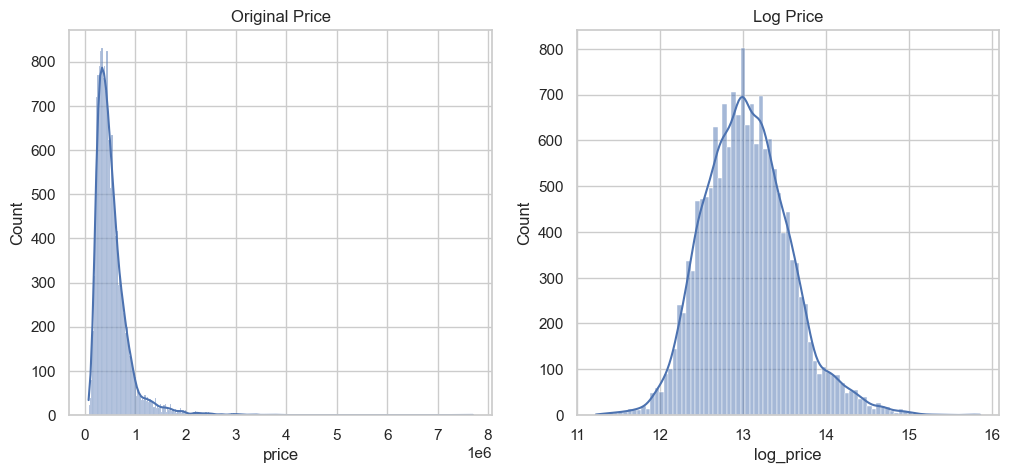

In [6]:
# Check skewness
print(f"Original Price Skew: {train_df['price'].skew():.2f}")

# Transform
train_df['log_price'] = np.log1p(train_df['price'])
print(f"Log Price Skew: {train_df['log_price'].skew():.2f}")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(train_df['price'], ax=ax1, kde=True).set_title("Original Price")
sns.histplot(train_df['log_price'], ax=ax2, kde=True).set_title("Log Price")
plt.show()

In [7]:
train_df.to_csv("../data/train_processed.csv", index=False)
test_df.to_csv("../data/test_processed.csv", index=False)
print("  Preprocessing Completed. Files saved for Model Training.")

  Preprocessing Completed. Files saved for Model Training.


In [8]:
df = pd.read_csv('../data/train_processed.csv')
target = 'log_price'
features = [
    'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 
    'waterfront', 'view', 'condition', 'grade', 'sqft_above', 
    'sqft_basement', 'yr_built', 'yr_renovated', 'lat', 'long',
    'sqft_living15', 'sqft_lot15', 'dist_to_downtown', 'cluster_id'
]

X = df[features]
y = df[target]

In [9]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
encoder = TargetEncoder(cols=['cluster_id'])
scaler = StandardScaler()

X_train_encoded = encoder.fit_transform(X_train, y_train)
X_val_encoded = encoder.transform(X_val)

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_val_scaled = scaler.transform(X_val_encoded)

C:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\category_encoders\ordinal.py:198: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[column] = X[column].astype("object").fillna(np.nan).map(col_mapping)
C:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\category_encoders\ordinal.py:198: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[column] = X[column].astype("object").fillna(np.nan).map(col_mapping)
C:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\category_encoders\ordinal.py:198: FutureWa

In [11]:
print("  Training XGBoost Baseline...")
model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    early_stopping_rounds=50
)

model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    verbose=False
)

  Training XGBoost Baseline...


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [12]:
preds = model.predict(X_val_scaled)
#Convert back from Log to actual Price
y_val_exp = np.expm1(y_val)
preds_exp = np.expm1(preds)

mae = mean_absolute_error(y_val_exp, preds_exp)
r2 = r2_score(y_val_exp, preds_exp)
rmse = np.sqrt(mean_squared_error(y_val_exp, preds_exp))

print(f"\n--- Baseline Results ---")
print(f"R² Score: {r2:.4f}")
print(f"MAE: $ {mae:,.2f}")
print(f"RMSE: $ {rmse:,.2f}")


--- Baseline Results ---
R² Score: 0.8888
MAE: $ 62,548.91
RMSE: $ 113,523.01


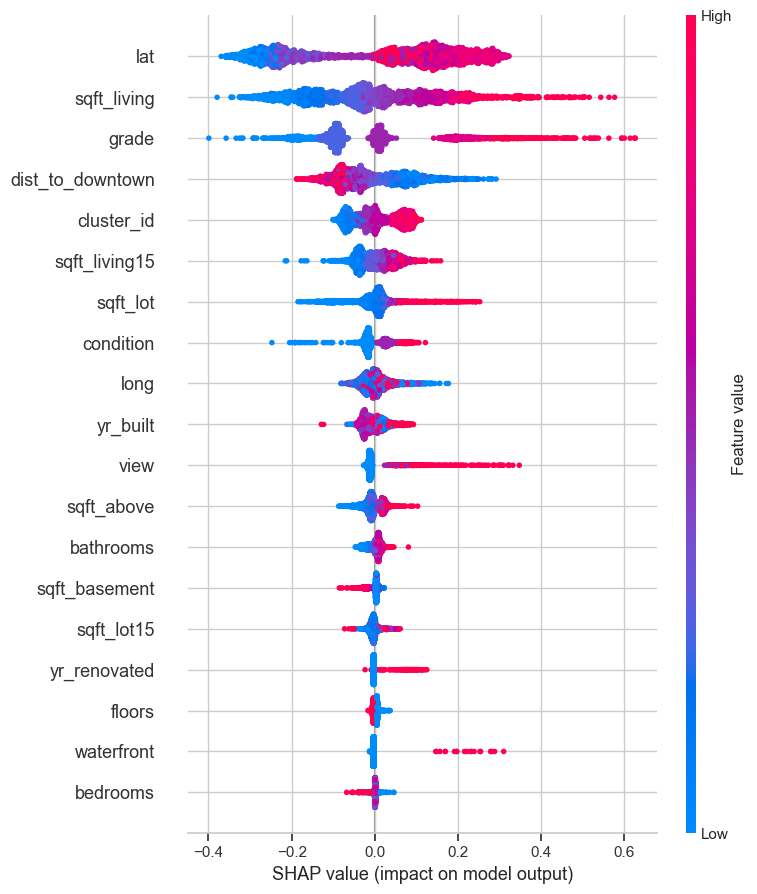

In [13]:
#SHAP Analysis
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val_scaled)

#Plot summary
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_val_encoded, feature_names=features)